# Tutorial 10 · A simulated rain field and every sensor: testing methods against the truth

Every earlier tutorial scored its maps and nowcasts against the radar or against gauges -
references with their own errors, and only where they are. A **simulation** knows the rain
everywhere and its motion exactly. This tutorial builds one from scratch, writing each step by
hand before calling the FieldSense version, then lets three sensors measure it and scores a map
against the truth at street level and at city scale.

| | |
|---|---|
| **Data** | none: everything is simulated (`core.simulation`) |
| **You will learn** | a Gaussian random field from its spectrum; turning it into rain with a given wet fraction; rain cells; moving a field without blurring it; what a link, a gauge and a radar measure, written out; why a map's accuracy depends on the scale it is judged at; motion estimates against the true motion |
| **Runtime** | about a minute |
| **Prerequisites** | [02 · Link signal to rain](02_cml_signal_to_rain.ipynb), [05 · 2D rain maps](05_2d_rain_maps.ipynb), [07 · Nowcasting](07_nowcasting_with_pysteps.ipynb) |

**Contents**
1. A correlated random field, by hand
2. From a Gaussian field to rain
3. Rain cells
4. Moving the field
5. Three sensors, written out
6. A map, and its accuracy at every scale
7. Motion against the truth
8. The FieldSense simulator and where it is used
9. References

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 100, "axes.grid": False})
rng = np.random.default_rng(42)

N, DX = 128, 0.25            # a 32 x 32 km domain at 250 m

## 1. A correlated random field, by hand

Rain is spatially correlated: neighbouring pixels rain alike. The standard way to simulate
correlated noise is in Fourier space. White noise has the same power at every wavenumber `k`;
multiplying its Fourier transform by `sqrt(S(k))` gives a field whose power spectrum is `S(k)`,
and by the Wiener-Khinchin theorem, whose covariance is the inverse transform of `S`.
For a power-law spectrum `S(k) ~ k^-beta`, larger `beta` puts more power at large scales:
a smoother field.

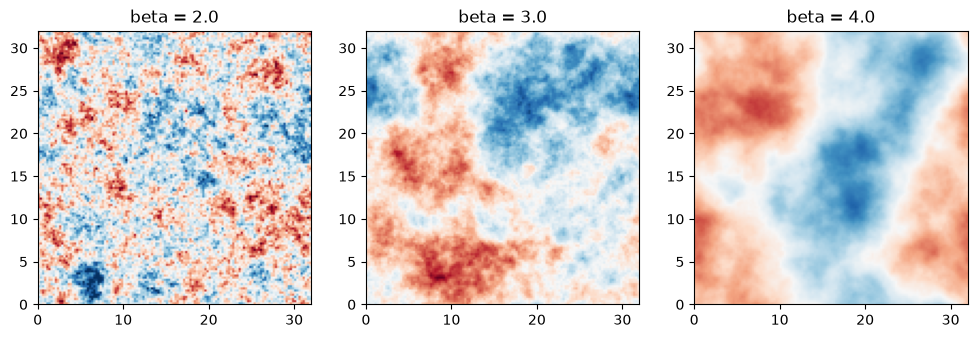

In [2]:
def gaussian_field(beta, n=N, dx=DX, rng=rng):
    k = np.hypot(*np.meshgrid(np.fft.fftfreq(n, dx), np.fft.fftfreq(n, dx)))
    k[0, 0] = np.inf                                   # no power in the mean
    noise = np.fft.fft2(rng.standard_normal((n, n)))   # white noise, in Fourier space
    g = np.fft.ifft2(noise * k ** (-beta / 2)).real    # filtered: power ~ k^-beta
    return (g - g.mean()) / g.std()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, beta in zip(axes, (2.0, 3.0, 4.0)):
    ax.imshow(gaussian_field(beta), origin="lower", cmap="RdBu_r", vmin=-3, vmax=3, extent=(0, 32, 0, 32))
    ax.set_title(f"beta = {beta}")

## 2. From a Gaussian field to rain

Rain is not Gaussian: most of the domain is dry, and wet values are skewed. The
**meta-Gaussian** transform keeps the field's correlation and imposes the distribution: the
`war` (wet-area ratio) highest values are wet, and each wet value's quantile is mapped onto a
chosen distribution of wet rain rates - here a lognormal with mean 3 mm/h and CV 1.2.

In [3]:
def to_rain(g, war=0.4, mean=3.0, cv=1.2):
    u = stats.norm.cdf(g)                              # quantile of each pixel
    wet = u > 1 - war
    q = np.clip((u - (1 - war)) / war, 1e-6, 1 - 1e-6) # quantile among the wet pixels
    s2 = np.log1p(cv ** 2)
    return np.where(wet, stats.lognorm(s=np.sqrt(s2), scale=mean * np.exp(-s2 / 2)).ppf(q), 0.0)

rain = to_rain(gaussian_field(3.2))
print(f"wet fraction {np.mean(rain > 0):.2f}, mean where wet {rain[rain > 0].mean():.2f} mm/h, max {rain.max():.0f} mm/h")

wet fraction 0.43, mean where wet 2.70 mm/h, max 13 mm/h


`core.simulation.generators` does the same with more covariances (Matern, exponential,
Gaussian, power law, with anisotropy) and an exact wet fraction:

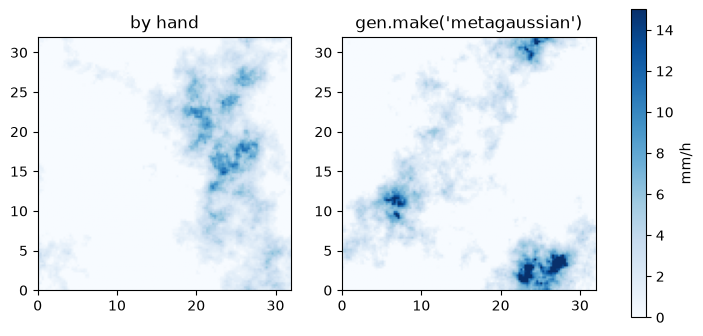

In [4]:
from core.simulation import generators as gen
from core.simulation.rain_fields import Grid

grid = Grid(n=N, dx_km=DX)
mg = gen.make("metagaussian", cov="powerlaw", beta=3.2, war=0.4, mean_wet_mm_h=3.0, seed=1).build(grid)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (t, f) in zip(axes, [("by hand", rain), ("gen.make('metagaussian')", mg)]):
    im = ax.imshow(f, origin="lower", cmap="Blues", vmax=15, extent=(0, 32, 0, 32)); ax.set_title(t)
fig.colorbar(im, ax=axes, label="mm/h");

## 3. Rain cells

Convective rain comes in cells: a few kilometres across, tens of mm/h at the core. A cell is a
2-D profile - an elliptical Gaussian here - and a field is a sum of cells with random positions,
peaks and sizes. The HyCell model (Feral et al. 2003) adds an exponential "skirt" of light rain
around each Gaussian core.

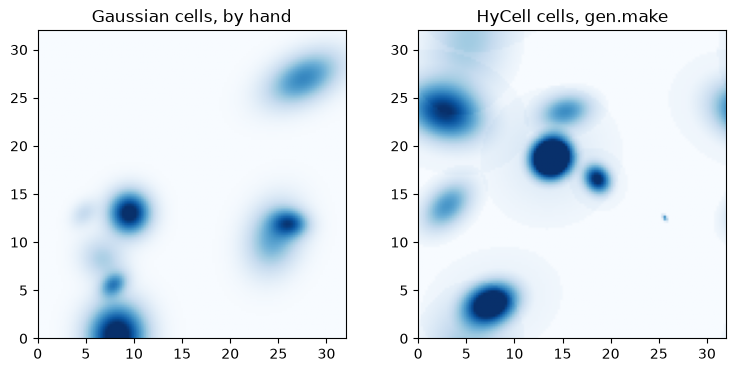

In [5]:
def cells_by_hand(n_cells=8, rng=rng):
    x = (np.arange(N) + 0.5) * DX
    X, Y = np.meshgrid(x, x)
    out = np.zeros((N, N))
    for _ in range(n_cells):
        x0, y0 = rng.uniform(0, 32, 2)
        peak, a = rng.gamma(2, 15), rng.uniform(1, 3)       # mm/h, km
        b, th = a * rng.uniform(0.5, 1), rng.uniform(0, np.pi)
        u = (X - x0) * np.cos(th) + (Y - y0) * np.sin(th)
        v = -(X - x0) * np.sin(th) + (Y - y0) * np.cos(th)
        out += peak * np.exp(-0.5 * ((u / a) ** 2 + (v / b) ** 2))
    return np.where(out > 0.1, out, 0)

hycell = gen.make("gaussian_cells", n_cells=8, poisson=False, profile="hycell", radius_km=2, seed=3).build(grid)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (t, f) in zip(axes, [("Gaussian cells, by hand", cells_by_hand()), ("HyCell cells, gen.make", hycell)]):
    ax.imshow(f, origin="lower", cmap="Blues", vmax=30, extent=(0, 32, 0, 32)); ax.set_title(t)

## 4. Moving the field

Shifting a field by a fraction of a pixel by interpolation blurs it, and the blur accumulates
step after step. On a periodic grid a shift is exact in Fourier space: a phase ramp
`exp(-2 pi i k . d)`. Real rain also changes as it moves; `core.simulation.spacetime` adds that
(AR(1) mixing with fresh realisations, scale-dependent decay, cell life cycles) on top of any
flow, uniform or not.

In [6]:
def shift(field, d_km):
    kx = np.fft.fftfreq(N, DX)[None, :]
    ky = np.fft.fftfreq(N, DX)[:, None]
    return np.fft.ifft2(np.fft.fft2(field) * np.exp(-2j * np.pi * (kx * d_km[0] + ky * d_km[1]))).real

u_kmh = np.array([24.0, 8.0])                      # the true motion
frames = np.stack([np.clip(shift(mg, u_kmh * t / 60), 0, None) for t in range(0, 61, 5)])  # every 5 min
print(frames.shape, "- the rain after 60 min is the rain at t=0 moved by", u_kmh, "km")

(13, 128, 128) - the rain after 60 min is the rain at t=0 moved by [24.  8.] km


## 5. Three sensors, written out

* **A rain gauge** catches the rain at one point (here: with a 0.2 mm tipping bucket).
* **A link** measures attenuation along its path: `A = L * mean(k R^alpha)` (ITU-R P.838-3),
  and retrieval inverts a power law - exact only if the rain were uniform along the path.
* **A radar** measures reflectivity `Z = a R^b`, averaged over its pixel, with an error of
  1-2 dB; the retrieval uses an assumed `a, b`.

In [7]:
from core.itu_p838 import get_k_alpha
from scipy.ndimage import map_coordinates

R = frames[6]                                       # rain at t = 30 min, mm/h
# a gauge where it rains hardest, one 5-min interval, tipping bucket 0.2 mm
iy, ix = np.unravel_index(R.argmax(), R.shape)
depth = R[iy, ix] * 5 / 60
print(f"gauge at ({(ix + 0.5) * DX:.1f}, {(iy + 0.5) * DX:.1f}) km: true {depth:.2f} mm, recorded {np.floor(depth / 0.2) * 0.2:.1f} mm")

# a 6 km link at 23 GHz from (8, 8) to (13, 11.3) km
k, alpha = get_k_alpha(23.0, "vertical")
s = np.linspace(0, 1, 100)
px, py = 8 + 5 * s, 8 + 3.3 * s
r_path = map_coordinates(R, [py / DX - 0.5, px / DX - 0.5], order=1)
L = np.hypot(5, 3.3)
A = L * np.mean(k * r_path ** alpha)
print(f"link: path mean {r_path.mean():.2f} mm/h, attenuation {A:.2f} dB, retrieved {(A / (k * L)) ** (1 / alpha):.2f} mm/h")

# a radar pixel of 1 km: Z averaged over the 4 x 4 truth pixels it covers, 1.5 dB of error
Z = 200 * R[:4, :4] ** 1.6
z_obs = 10 * np.log10(Z.mean() + 1e-9) + rng.normal(0, 1.5)
print(f"radar: true pixel mean {R[:4, :4].mean():.2f} mm/h, retrieved {(10 ** (z_obs / 10) / 200) ** (1 / 1.6):.2f} mm/h")

gauge at (3.9, 6.9) km: true 5.72 mm, recorded 5.6 mm
link: path mean 3.27 mm/h, attenuation 2.37 dB, retrieved 3.21 mm/h
radar: true pixel mean 1.02 mm/h, retrieved 1.08 mm/h


`core.simulation.sensors` runs these over whole networks and storms, with the errors that matter
in practice (wet antenna, baseline drift, wet/dry classification for links; attenuation, beam
broadening, overshooting, calibration for the radar; undercatch and faults for gauges), and
`core.simulation.scenario` returns them as the xarray data the map code reads.

## 6. A map, and its accuracy at every scale

A scenario: the truth at 100 m and 1 min over a 12.8 km city, a C-band radar at 800 m, 120 links
and 30 weather stations, every map on a 200 m grid. How good is a map? It depends on the scale
at which it is judged: a street (100 m, 5 min) or a district (3.2 km, an hour).

In [8]:
from core.simulation import benchmark as bm, sensors as sn
from core.simulation.scenario import Scenario

case = Scenario(model="clustered_storms", model_params={"n_cells": 4, "texture_strength": 0.35},
                n=128, dx_km=0.1, analysis_factor=2, duration_min=60, n_links=120, n_gauges=0, n_pws=30,
                radar=sn.RadarConfig(resolution_km=0.8, site_km=(-25, -10)), flow_params={"mean": (20, 5)},
                evolution="lifecycle", evolution_params={"lifetime_min": 60}, seed=5).run()
products = bm.maps(case, sensor_sets=("links", "links+pws"), with_mergeplg=False, with_gmz=False)
products = {k: products[k] for k in ("radar", "idw links", "add [links]", "add [links+pws]")}
scales = bm.score_scales(case, products, space_km=(0.1, 0.4, 1.6, 6.4), time_min=(5, 60))
scales.pivot_table(index="method", columns=["time_min", "space_km"], values="nrmse").round(2)

time_min           5                       60                  
space_km          0.1   0.4   1.6   6.4   0.1   0.4   1.6   6.4
method                                                         
add [links+pws]  2.15  2.07  1.36  0.65  0.73  0.70  0.58  0.32
add [links]      2.18  2.10  1.40  0.69  0.73  0.71  0.59  0.32
idw links        2.77  2.72  2.19  0.82  1.21  1.19  1.03  0.48
radar            2.29  2.23  1.55  0.61  0.54  0.52  0.39  0.22

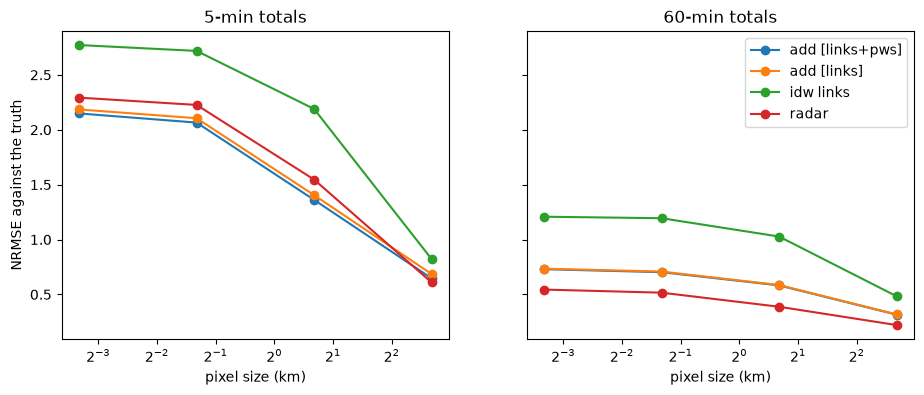

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, m in zip(axes, (5, 60)):
    for name, d in scales[scales.time_min == m].groupby("method"):
        ax.plot(d.space_km, d.nrmse, marker="o", label=name)
    ax.set_xscale("log", base=2); ax.set_title(f"{m}-min totals"); ax.set_xlabel("pixel size (km)")
axes[0].set_ylabel("NRMSE against the truth"); axes[1].legend();

Every map improves as the pixels grow and the accumulation lengthens. At street level and
5 minutes the errors are about twice the mean rain - no map resolves individual streets in
a convective storm - while at 6.4 km and an hour they fall to between a fifth and a half of it. Which
product is best depends on the scale: for 5-minute totals at fine scales the radar adjusted
with the links is ahead of the radar; for hourly totals the radar alone is best in this
scenario, because the links (retrieval errors, uneven coverage) add more error than they
remove. One scenario says little; `projects/simulation/testbed` runs this over many scenarios
with every method and two radars.

## 7. Motion against the truth

Optical flow cannot be checked on real data: the true wind that carries the rain is unknown.
Here it is known.

In [10]:
from core.nowcast import methods as nm

meta = bm.nowcast_meta(case)
rate = case.rate
truth_v = case.velocity
for method in ("LK", "VET"):
    v = nm.motion(rate[:8], meta, method)
    err = bm.score_motion(v, truth_v, rate[7] > 0.1, case.pixel_km * 60 / case.interval_min)
    print(f"{method}: endpoint error {err['epe_kmh']:.1f} km/h, direction error {err['dir_err_deg']:.0f} deg "
          f"(true speed {np.hypot(*case.velocity_kmh.mean((1, 2))):.0f} km/h)")

Pysteps configuration file found at: /Users/drorjac/.pysteps/pystepsrc



LK: endpoint error 8.1 km/h, direction error 9 deg (true speed 21 km/h)


VET: endpoint error 6.5 km/h, direction error 13 deg (true speed 21 km/h)


## 8. The FieldSense simulator and where it is used

| module | what it adds |
|---|---|
| `core.simulation.generators` | ten rain models by name: Gaussian/HyCell cells (clustered in storms), meta-Gaussian, RainFARM, cascades, universal multifractals, three classical regimes |
| `core.simulation.cloud_model` | a physical warm-rain model: rain that grows and decays from vapour, updrafts and microphysics |
| `core.simulation.flows`, `.spacetime` | uniform, rotating, sheared, random flows; four evolutions; the true velocity |
| `core.simulation.sensors`, `.scenario` | radar, links, gauges and PWS with their errors, as the data of real networks |
| `core.simulation.benchmark` | every map, merging, motion and nowcast method scored against the truth, by scale |
| `core.nowcast.learned_motion` | a motion network trained on the true flow |

[`projects/simulation/testbed`](../projects/simulation/testbed/) runs all of it over many
scenarios, regional and street-level; [`projects/simulation/regimes`](../projects/simulation/regimes/)
asks what limits a map made from links alone.

## 9. References

* Bowler, Pierce & Seed (2006). STEPS. *Q. J. R. Meteorol. Soc.* 132, 2127-2155. [doi:10.1256/qj.04.100](https://doi.org/10.1256/qj.04.100)
* Feral, Sauvageot, Castanet & Lemorton (2003). HYCELL - A new hybrid model of the rain horizontal distribution for propagation studies: 1. *Radio Sci.* 38. [doi:10.1029/2002RS002802](https://doi.org/10.1029/2002RS002802)
* Paschalis, Molnar, Fatichi & Burlando (2013). A stochastic model for high-resolution space-time precipitation simulation (STREAP). *Water Resour. Res.* 49, 8400-8417. [doi:10.1002/2013WR014437](https://doi.org/10.1002/2013WR014437)
* Rebora, Ferraris, von Hardenberg & Provenzale (2006). RainFARM. *J. Hydrometeor.* 7, 724-738. [doi:10.1175/JHM517.1](https://doi.org/10.1175/JHM517.1)
* Schertzer & Lovejoy (1987). Physical modeling and analysis of rain and clouds by anisotropic scaling multiplicative processes. *JGR* 92, 9693-9714. [doi:10.1029/JD092iD08p09693](https://doi.org/10.1029/JD092iD08p09693)
* ITU-R P.838-3 (2005). Specific attenuation model for rain for use in prediction methods. [itu.int](https://www.itu.int/rec/R-REC-P.838-3-200503-I/en)